In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math

import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=7, palette=sns.color_palette('Set2'),)

from rna_vel_pred import plots

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
alt_ids = duckdb.sql("""
select
    alt_id,
    H5adUMap.dataset,
    time_step_count_sparsify,
    neighbor_count
from Conf
join Conf__Dataset
    on Conf.id = Conf__Dataset.Conf
join Dataset
    on Dataset.id = Conf__Dataset.Dataset
join H5adUMap
    on Dataset.id = H5adUMap.id
join Trainable
    on Conf.Model = Trainable.id
join First
    on Trainable.id = First.id
where
    fit
and
    umap_dimension = 2
and
    -- time_step_count_sparsify in (4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 48)
    time_step_count_sparsify in (10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150)
and
    -- neighbor_count in (4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 100, 200, 1000)
    neighbor_count in (10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150)
and
    epoch_count = 50
and
    Conf.id not in (
        select
            Conf.id
        from Conf
        join Conf__Dataset
            on Conf.id = Conf__Dataset.Conf
        join Dataset
            on Conf__Dataset.Dataset = Dataset.id
        join H5adUMap
            on Dataset.id = H5adUMap.id
        group by
            Conf.id
            having count(Conf.id) > 1
    )
-- and
--     H5adUMap.dataset != 'FOREBRAIN'
order by
    H5adUMap.dataset,
    time_step_count_sparsify,
    neighbor_count
;
""").pl()
alt_ids

alt_id,dataset,time_step_count_sparsify,neighbor_count
str,str,i64,i64
"""a9c64eos""","""BONEMARROW""",10,10
"""4x3nbonq""","""BONEMARROW""",10,20
"""ho0scl1h""","""BONEMARROW""",10,30
"""basu6szj""","""BONEMARROW""",10,40
"""xuu5y53p""","""BONEMARROW""",10,50
…,…,…,…
"""vam58kqd""","""PANCREAS""",100,110
"""5q2dopr8""","""PANCREAS""",100,120
"""szkaz6zn""","""PANCREAS""",100,130


In [5]:
duckdb.sql("""
set variable time_step_times_filepaths = (
    select list(format('~/out/rna_vel_pred/runs/{}/metrics.csv', alt_id)) from alt_ids
);
""")

In [6]:
loss = duckdb.sql("""
select
    csvs.alt_id,
    dataset,
    time_step_count_sparsify,
    neighbor_count,
    min(val_loss)
from (
    select
        split(filename, '/')[-2] as alt_id,
        step,
        val_loss
    from read_csv(getvariable(time_step_times_filepaths), filename=true, union_by_name=true)
    where val_loss is not null
) as csvs
join alt_ids
    on alt_ids.alt_id = csvs.alt_id
group by
    csvs.alt_id,
    dataset,
    time_step_count_sparsify,
    neighbor_count
order by
    dataset,
    time_step_count_sparsify,
    neighbor_count
;
""").pl()
loss

alt_id,dataset,time_step_count_sparsify,neighbor_count,min(val_loss)
str,str,i64,i64,f64
"""a9c64eos""","""BONEMARROW""",10,10,0.717786
"""4x3nbonq""","""BONEMARROW""",10,20,0.676717
"""ho0scl1h""","""BONEMARROW""",10,30,0.643596
"""basu6szj""","""BONEMARROW""",10,40,0.617633
"""xuu5y53p""","""BONEMARROW""",10,50,0.574469
…,…,…,…,…
"""vam58kqd""","""PANCREAS""",100,110,0.458673
"""5q2dopr8""","""PANCREAS""",100,120,0.458673
"""szkaz6zn""","""PANCREAS""",100,130,0.458673


In [7]:
loss.filter(time_step_count_sparsify=30, neighbor_count=150)

alt_id,dataset,time_step_count_sparsify,neighbor_count,min(val_loss)
str,str,i64,i64,f64
"""q2g5yltm""","""BONEMARROW""",30,150,0.277641
"""mwvca4bd""","""DENTATE_GYRUS""",30,150,0.372359
"""lu788fkq""","""FOREBRAIN""",30,150,0.640434
"""238cgiag""","""PANCREAS""",30,150,0.452013


In [8]:
loss.filter(dataset='DENTATE_GYRUS')

alt_id,dataset,time_step_count_sparsify,neighbor_count,min(val_loss)
str,str,i64,i64,f64
"""vkil6l80""","""DENTATE_GYRUS""",10,10,0.781317
"""g1s7g0py""","""DENTATE_GYRUS""",10,20,0.76182
"""elasgt2n""","""DENTATE_GYRUS""",10,30,0.745282
"""1fiyru2v""","""DENTATE_GYRUS""",10,40,0.720423
"""tq7y98sl""","""DENTATE_GYRUS""",10,50,0.695552
…,…,…,…,…
"""rkps742g""","""DENTATE_GYRUS""",100,110,0.406448
"""perkarkj""","""DENTATE_GYRUS""",100,120,0.406448
"""ky2s8qar""","""DENTATE_GYRUS""",100,130,0.406448


In [9]:
dataset_sizes = pl.DataFrame(list(zip(*{
    'PANCREAS': 3696,
    'BONEMARROW': 5780,
    'DENTATE_GYRUS': 2930,
    'FOREBRAIN': 20898
}.items())), schema=['dataset', 'measurement_count'])
dataset_sizes

dataset,measurement_count
str,i64
"""PANCREAS""",3696
"""BONEMARROW""",5780
"""DENTATE_GYRUS""",2930
"""FOREBRAIN""",20898


In [16]:
loss_pivot = (
    loss
    .join(dataset_sizes, on='dataset')
    .with_columns(sparsity=pl.col('time_step_count_sparsify') / pl.col('measurement_count'))
    .filter(dataset='PANCREAS')
    .select('neighbor_count', 'sparsity', 'min(val_loss)')
    .pivot(on='neighbor_count', index='sparsity')
    .to_pandas()
    .set_index('sparsity')
)
loss_pivot.index = loss_pivot.index.rename('Sparsification step size')
loss_pivot.columns = loss_pivot.columns.map(int).rename('Number of neighbors')
loss_pivot = loss_pivot.sort_index(axis=1)

In [17]:
loss_pivot.T

Sparsification step size,0.002706,0.005411,0.008117,0.010823,0.013528,0.016234,0.018939,0.021645,0.024351,0.027056
Number of neighbors,,,,,,,,,,
10,0.679814,0.630898,0.617302,0.620582,0.594975,0.606679,0.577342,0.570822,0.552780,0.539880
20,0.603732,0.610671,0.580086,0.565197,0.539142,0.504767,0.480016,0.462040,0.452685,0.446181
30,0.598508,0.570980,0.552484,0.501420,0.470776,0.450692,0.443868,0.435609,0.434318,0.451956
40,0.591702,0.566013,0.500348,0.462407,0.445279,0.436501,0.436646,0.449258,0.454808,0.458673
50,0.595621,0.547715,0.470795,0.445051,0.428800,0.450501,0.449841,0.453919,0.455087,0.458673
60,0.567808,0.498654,0.452354,0.436513,0.448131,0.450114,0.456405,0.453919,0.455087,0.458673
70,0.565708,0.480810,0.443502,0.430645,0.449536,0.453245,0.456405,0.453919,0.455087,0.458673
80,0.560637,0.462216,0.437231,0.446293,0.455758,0.453245,0.456405,0.453919,0.455087,0.458673
90,0.553716,0.452698,0.426513,0.450264,0.455758,0.453245,0.456405,0.453919,0.455087,0.458673


In [18]:
best_idx = np.unravel_index(loss_pivot.fillna(1e6).to_numpy().argmin(), loss_pivot.shape)
print(f'Best: Sparsity={loss_pivot.index[best_idx[0]]}, Neighbor count={loss_pivot.columns[best_idx[1]]}')

Best: Sparsity=0.005411255411255411, Neighbor count=130


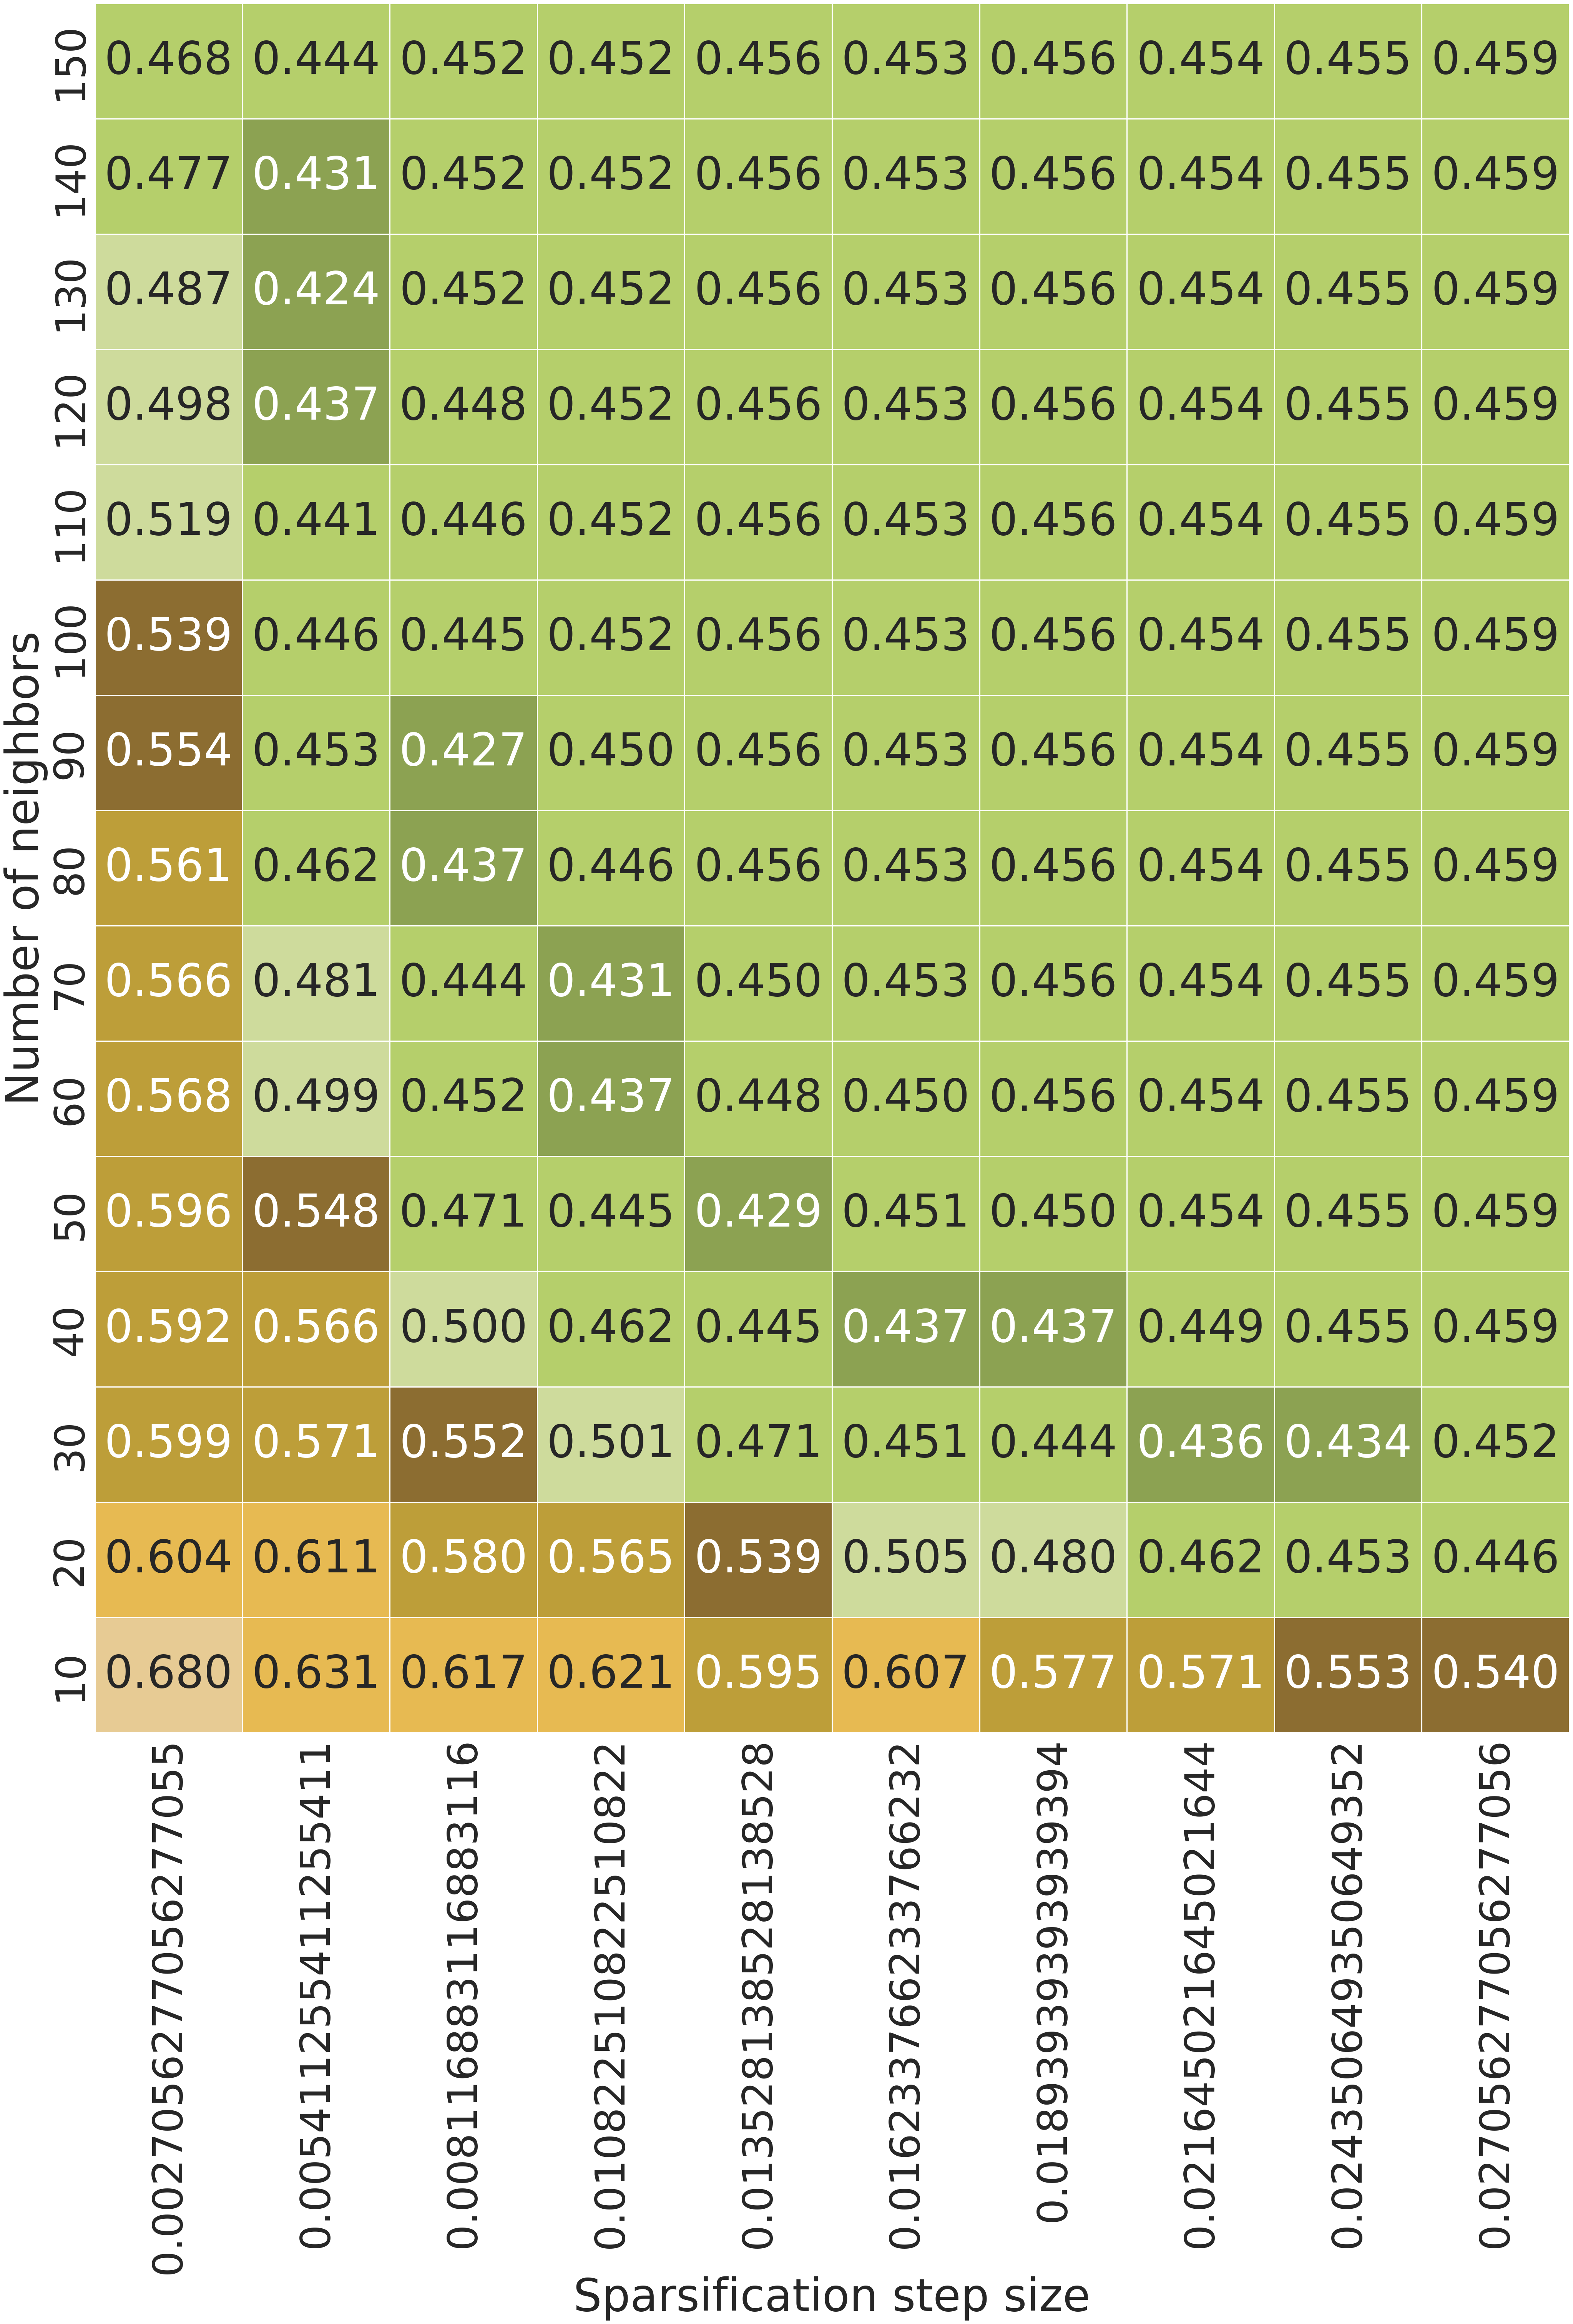

In [73]:
scale = 1.5
fig, (ax, ax_cbar) = plt.subplots(2, 1, height_ratios=[20, 1], figsize=(33*scale, 45*scale))
# colors = np.vstack([
#     c(np.linspace(0, 1, 2)) for c in [
#         # plt.cm.Greys_r,
#         plt.cm.Blues_r,
#         # plt.cm.Greens_r,
#         plt.cm.Oranges_r,
#         # plt.cm.Reds_r,
#         plt.cm.Purples_r,
#     ]
# ])
# rmse_max = math.ceil(loss_pivot.max().max())
# cmap = matplotlib.colors.LinearSegmentedColormap.from_list('my_cmap', colors)
rmse_max = 5
(
    sns.heatmap(
        data=loss_pivot.T,
        linewidths=1,
        annot=True,
        fmt='.3f',
        cmap='tab20b',
        # cmap=cmap,
        vmax=1,
        vmin=.2,
        ax=ax,
        cbar_ax=ax_cbar,
        cbar_kws=dict(
            orientation='horizontal',
        ),
    )
)
# formatter = plots.ScalarFormatter({tic: i for tic, i in zip(ax.get_yticks(), loss_pivot.index)}, useMathText=True)
# formatter.set_powerlimits((-0, -0))
# formatter.set_scientific(True)
# ax.yaxis.set_major_formatter(formatter)
# ax.remove()
# fig.savefig('Tune.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)
ax_cbar.remove()
ax.invert_yaxis()
fig.savefig('Tune.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)